<a href="https://colab.research.google.com/github/JohnDakultor/DeepTalk/blob/main/gpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.2 MB/s eta 0:00:00


Start of input ebeddings pipeline

In [2]:
from importlib.metadata import version
import tiktoken
import torch

In [3]:
tokenizer = tiktoken.get_encoding("gpt2")

text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)

integer = tokenizer.encode(text,  allowed_special={"<|endoftext|>"})
print(integer)


strings = tokenizer.decode(integer)
print(strings)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]
Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader

class DataSetV1(Dataset):

      def __init__(self,  txt, tokenizer, max_length, stride):
          self.input_ids = []
          self.target_ids = []



          token_ids = tokenizer.encode(txt)    #1

          for i in range(0, len(token_ids) - max_length, stride):     #2
              input_chunk = token_ids[i:i + max_length]
              target_chunk = token_ids[i + 1: i + max_length + 1]

              self.input_ids.append(torch.tensor(input_chunk))
              self.target_ids.append(torch.tensor(target_chunk))

      def __len__(self):    #3
        return len(self.input_ids)

      def __getitem__(self, idx):         #4
        return self.input_ids[idx], self.target_ids[idx]


In [5]:
def Create_DataLoader(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):


    tokenizer = tiktoken.get_encoding("gpt2")                         #1
    dataset = DataSetV1(txt, tokenizer, max_length, stride)   #2
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,

        drop_last=drop_last,     #3
        num_workers=num_workers     #4
    )

    return dataloader

In [6]:
with open("The Verdict.txt", "r", encoding="utf-8") as f:
    txt = f.read()


loader = Create_DataLoader(txt, batch_size=4, max_length=8,
                         stride=2, shuffle=False)

data = iter(loader)
first_batch = next(data)
print(first_batch)


[tensor([[   40,   367,  2885,  1464,  1807,  3619,   402,   271],
        [ 2885,  1464,  1807,  3619,   402,   271, 10899,  2138],
        [ 1807,  3619,   402,   271, 10899,  2138,   257,  7026],
        [  402,   271, 10899,  2138,   257,  7026, 15632,   438]]), tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899],
        [ 1464,  1807,  3619,   402,   271, 10899,  2138,   257],
        [ 3619,   402,   271, 10899,  2138,   257,  7026, 15632],
        [  271, 10899,  2138,   257,  7026, 15632,   438,  2016]])]


In [7]:
second_batch = next(data)
print(second_batch)

[tensor([[10899,  2138,   257,  7026, 15632,   438,  2016,   257],
        [  257,  7026, 15632,   438,  2016,   257,   922,  5891],
        [15632,   438,  2016,   257,   922,  5891,  1576,   438],
        [ 2016,   257,   922,  5891,  1576,   438,   568,   340]]), tensor([[ 2138,   257,  7026, 15632,   438,  2016,   257,   922],
        [ 7026, 15632,   438,  2016,   257,   922,  5891,  1576],
        [  438,  2016,   257,   922,  5891,  1576,   438,   568],
        [  257,   922,  5891,  1576,   438,   568,   340,   373]])]


In [8]:
loader = Create_DataLoader(txt, batch_size=8, max_length=4,
                         stride=4, shuffle=False)

In [9]:
data = iter(loader)
target_ids, input_ids = next(data)
print("Inputs:\n", target_ids)
print("\nTargets:\n", input_ids)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


In [10]:
input_ids = torch.tensor([2, 3, 5, 1])

In [11]:
vocab_size = 6
output_dim = 3

In [12]:
torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [13]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


In [14]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(token_embedding_layer.weight)

Parameter containing:
tensor([[-2.1338,  1.0524, -0.3885,  ...,  0.2461,  1.2119,  0.3171],
        [ 1.2277, -0.4297, -2.2121,  ..., -0.1640, -0.3348, -0.0221],
        [ 1.3382,  0.2706,  0.5071,  ...,  0.0175, -2.1517,  0.3924],
        ...,
        [-1.4889, -1.2456,  1.8034,  ..., -0.6392, -1.4939,  0.3614],
        [-1.0703,  0.2795, -0.2637,  ..., -0.2810, -1.4755, -0.1183],
        [-0.0071,  0.4982, -0.3319,  ...,  0.4970,  0.9365, -0.2091]],
       requires_grad=True)


In [15]:
token_embeddings = token_embedding_layer(target_ids)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


For a GPT model’s absolute embedding approach, we just need to create another embedding layer that has the same embedding dimension as the token_embedding_ layer:

In [16]:
context_lenth = 4
pos_embedding_layers = torch.nn.Embedding(context_lenth, output_dim)
pos_embeddings = pos_embedding_layers(torch.arange(context_lenth))
print(pos_embeddings.shape)


torch.Size([4, 256])


In [17]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


End of input embeddings pipeline.

Simple self attention mechanism

In [18]:
import torch
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [19]:
query = inputs[1]                            #1
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)
print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [20]:
res = 0.
for idx, element in enumerate(inputs[0]):
    res += inputs[0][idx] * query[idx]
print(res)
print(torch.dot(inputs[0], query))

tensor(0.9544)
tensor(0.9544)


In [21]:
att_weights_2 = torch.softmax(attn_scores_2, dim=0)
print(att_weights_2)
print(torch.sum(att_weights_2))

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor(1.)


In [22]:
query = inputs[1]
context_vector = torch.zeros(inputs.shape)
for i, x_i in enumerate(inputs):
    context_vector += att_weights_2[i] * x_i
print(context_vector)

tensor([[0.4419, 0.6515, 0.5683],
        [0.4419, 0.6515, 0.5683],
        [0.4419, 0.6515, 0.5683],
        [0.4419, 0.6515, 0.5683],
        [0.4419, 0.6515, 0.5683],
        [0.4419, 0.6515, 0.5683]])


 calculate attention weights and context vectors for all inputs

In [23]:
attn_score = inputs @ inputs.T
print(attn_score)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [24]:
attn_weights = torch.softmax(attn_score, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [25]:
all_context_vec = attn_weights @ inputs
print(all_context_vec)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


 self-attention mechanism with trainable weights

In [26]:
x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2

In [27]:
torch.manual_seed(123)
W_q = torch.rand(d_in, d_out, requires_grad=False)
W_k = torch.rand(d_in, d_out, requires_grad=False)
W_v = torch.rand(d_in, d_out, requires_grad=False)

In [28]:
query2 = x_2 @ W_q
key2 = inputs @ W_k
value2 = inputs @ W_v
print(query2)

tensor([0.4306, 1.4551])


In [29]:
keys = inputs @ W_k
values = inputs @ W_v
print(keys.shape)
print(values.shape)

torch.Size([6, 2])
torch.Size([6, 2])


In [30]:
keys2 = keys[1]
attn_score_22 = query2.dot(keys2)
print(attn_score_22)

tensor(1.8524)


In [31]:
attn_scores_2 = query2 @ keys.T
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [32]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [33]:
context_vec = attn_weights_2 @ values
print(context_vec)

tensor([0.3061, 0.8210])


code to compute all context vectors in the input sequence (python class)

In [34]:
import torch.nn as nn

class Self_attention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_q = nn.Parameter(torch.rand(d_in, d_out))
        self.W_k = nn.Parameter(torch.rand(d_in, d_out))
        self.W_v = nn.Parameter(torch.rand(d_in, d_out))


    def forward(self, inputs):
        query = inputs @ self.W_q
        keys = inputs @ self.W_k
        values = inputs @ self.W_v
        attn_scores = query @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec

In [35]:
torch.manual_seed(123)
model1 = Self_attention_v1(d_in, d_out)
context_vec1 = model1(inputs)
print(context_vec)

tensor([0.3061, 0.8210])


In [36]:
import torch.nn as nn

class Self_attention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_q = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_k = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_v = nn.Linear(d_in, d_out, bias=qkv_bias)


    def forward(self, inputs):
        query = self.W_q(inputs)
        keys = self.W_k(inputs)
        values = self.W_v(inputs)
        attn_scores = query @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec

In [37]:
torch.manual_seed(789)
model2 = Self_attention_v2(d_in, d_out)
context_vec2 = model2(inputs)
print(context_vec)

tensor([0.3061, 0.8210])


In [38]:
queries = model2.W_q(inputs)
keys = model2.W_k(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [39]:
context_len = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_len, context_len))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [40]:
masked_simple = attn_weights * mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [41]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)


tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


In [42]:
mask = torch.triu(torch.ones(context_len, context_len), diagonal=1)
print(mask)

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])


In [43]:
masked = attn_scores.masked_fill(mask.bool(), float("-inf"))
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [44]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [45]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
attn_weights_drop = dropout(attn_weights)
print(attn_weights_drop)

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.8966, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4921, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4350, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.0000, 0.0000, 0.0000, 0.0000]],
       grad_fn=<MulBackward0>)


coding a compact python class for causal attention

In [46]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


In [47]:
class Causal_Attention(nn.Module):
  def __init__(self,d_in, d_out, context_length, dropout, qkv_bias=False):
      super().__init__()
      self.W_q = nn.Linear(d_in, d_out, bias=qkv_bias)
      self.W_k = nn.Linear(d_in, d_out, bias=qkv_bias)
      self.W_v = nn.Linear(d_in, d_out, bias=qkv_bias)
      self.dropout = nn.Dropout(dropout)
      self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))


  def forward(self, inputs):
      b, num_tokens, d_in = inputs.shape
      keys = self.W_k(inputs)
      queries = self.W_q(inputs)
      values = self.W_v(inputs)

      attn_scores = queries @ keys.transpose(1, 2)
      attn_scores = attn_scores.masked_fill(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
      attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
      attn_weights_drop = self.dropout(attn_weights)
      context_vec = attn_weights_drop @ values

      return context_vec


In [48]:
torch.manual_seed(123)
context_lenth = batch.shape[1]
ca = Causal_Attention(d_in, d_out, context_lenth, 0.0)
context_vec = ca(batch)
print(context_vec.shape)

torch.Size([2, 6, 2])


In [49]:
class Multi_Head_Attention_Wrapper(nn.Module):
    def __init__(self, d_in, d_out, num_heads, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [
                Causal_Attention(d_in, d_out, context_length, dropout, qkv_bias)
                for _ in range(num_heads)
            ]
        )

    def forward(self, inputs):
        context_vectors = torch.cat([head(inputs) for head in self.heads], dim=-1)
        return context_vectors

In [50]:
torch.manual_seed(123)
context_lenth = batch.shape[1]
ma = Multi_Head_Attention_Wrapper(d_in, d_out, num_heads=2, context_length=context_lenth, dropout=0.0)
context_vec = ma(batch)
print(context_vec)
print(context_vec.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
torch.Size([2, 6, 4])


implementing multiheads attention with weight splits efficiently

In [51]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out,
                 context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads    #1
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)    #2
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)         #3
        queries = self.W_query(x)    #3
        values = self.W_value(x)     #3

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)       #4
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(
            b, num_tokens, self.num_heads, self.head_dim
        )

        keys = keys.transpose(1, 2)          #5
        queries = queries.transpose(1, 2)    #5
        values = values.transpose(1, 2)      #5


        attn_scores = queries @ keys.transpose(2, 3)   #6
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]    #7

        attn_scores.masked_fill_(mask_bool, -torch.inf)     #8

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)   #9
 #10
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )
        context_vec = self.out_proj(context_vec)    #11
        return context_vec

In [52]:
torch.manual_seed(123)
batch_size, context_lenth, d_in = batch.shape
d_out = 12
ma = MultiHeadAttention(d_in, d_out, context_lenth, 0.0, num_heads=12)
context_vec = ma(batch)

print(context_vec)
print(context_vec.shape)

tensor([[[ 0.1459, -0.3421,  0.1385,  0.0031,  0.2925, -0.5214,  0.5882,
          -0.1075,  0.0167,  0.2416,  0.1121,  0.2292],
         [ 0.0641, -0.2498,  0.0535, -0.0513,  0.3659, -0.6262,  0.5790,
          -0.1392,  0.0592,  0.1866,  0.1456,  0.2195],
         [ 0.0377, -0.2181,  0.0232, -0.0699,  0.3911, -0.6600,  0.5776,
          -0.1500,  0.0738,  0.1668,  0.1540,  0.2168],
         [ 0.0578, -0.1960,  0.0084, -0.0699,  0.3525, -0.6252,  0.5319,
          -0.1017,  0.0407,  0.1393,  0.1244,  0.2152],
         [ 0.0504, -0.2149, -0.0127, -0.0668,  0.3714, -0.5897,  0.5301,
          -0.0764,  0.0478,  0.1126,  0.0827,  0.2483],
         [ 0.0628, -0.1944, -0.0104, -0.0658,  0.3471, -0.5917,  0.5073,
          -0.0667,  0.0275,  0.1101,  0.0911,  0.2314]],

        [[ 0.1459, -0.3421,  0.1385,  0.0031,  0.2925, -0.5214,  0.5882,
          -0.1075,  0.0167,  0.2416,  0.1121,  0.2292],
         [ 0.0641, -0.2498,  0.0535, -0.0513,  0.3659, -0.6262,  0.5790,
          -0.1392,  0.

 Implementing a GPT model from scratch to generate text (using gpt2 as base model)

In [53]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}




 A placeholder GPT model architecture class

In [54]:


import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(               #1
            *[DummyTransformerBlock(cfg)               #1
              for _ in range(cfg["n_layers"])]         #1
        )                                              #1
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])     #2
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):    #3
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):     #4
        return x





class DummyLayerNorm(nn.Module):           #5
    def __init__(self, normalized_shape, eps=1e-5):    #6
        super().__init__()

    def forward(self, x):
        return x

In [55]:
import tiktoken

batch = []
tokenizer = tiktoken.get_encoding("gpt2")
text1 = 'Every effort moves you'
text2 = 'Every day holds a'

batch.append(torch.tensor(tokenizer.encode(text1)))
batch.append(torch.tensor(tokenizer.encode(text2)))

batch = torch.stack(batch, dim=0)
print(batch)


tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [56]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print(logits.shape)
print(logits)

torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


Layer Noirmalization class

In [57]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [58]:
batch_example = torch.randn(2, 5)
print(batch_example)

tensor([[ 0.1262,  1.6740,  0.9943,  0.3404,  1.2790],
        [-1.3698,  1.0055, -0.1564,  0.3283,  0.6466]])


In [59]:
# torch.set_printoptions(sci_mode=False)

In [60]:
ln = LayerNorm(emb_dim=5)
ln_out = ln(batch_example)
mean = ln_out.mean(dim=-1, keepdim=True)
var = ln_out.var(dim=-1, keepdim=True, unbiased=False)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[ 3.5763e-08],
        [-2.3842e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [61]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

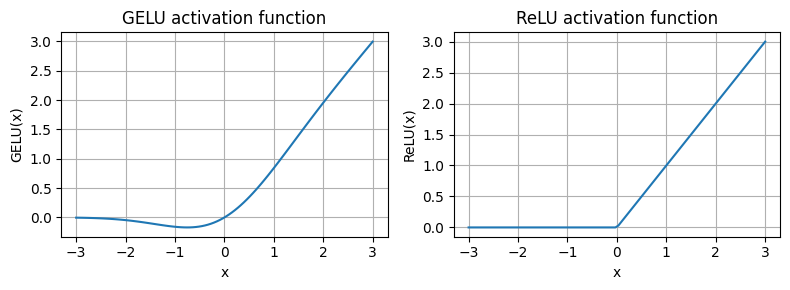

In [62]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)     #1
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )



    def forward(self, x):
        return self.layers(x)

 A neural network to illustrate shortcut connections

In [64]:


class ExampleDeepNeuralNetwork_Shortcut(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([       #1
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]),
                          GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)         #2
            if self.use_shortcut and x.shape == layer_output.shape:    #3
                x = x + layer_output
            else:
                x = layer_output
        return x

In [65]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)                            #1
model_without_shortcut = ExampleDeepNeuralNetwork_Shortcut(
    layer_sizes, use_shortcut=False
)

In [66]:
def print_gradients(model, x):
    output = model(x)             #1
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target)    #2

    loss.backward()          #3

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [67]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


In [68]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork_Shortcut(
    layer_sizes, use_shortcut=True

)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


 Connecting attention and linear layers in a transformer block

In [69]:
# from chapter03 import MultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, input):
 #1
        shortcut = input

        input = self.norm1(input)
        input = self.att(input)
        input = self.drop_shortcut(input)
        input = input + shortcut      #2

        shortcut = input         #3
        input = self.norm2(input)
        input = self.ff(input)
        input = self.drop_shortcut(input)
        input = input + shortcut      #4
        return input

 The GPT model architecture implementation

In [70]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
 #1
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)


        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [71]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
logits = model(batch)
print(batch)
print(logits.shape)
print(logits)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
torch.Size([2, 4, 50257])
tensor([[[ 0.1381,  0.0077, -0.1963,  ..., -0.0222, -0.1060,  0.1717],
         [ 0.3865, -0.8408, -0.6564,  ..., -0.5163,  0.2369, -0.3357],
         [ 0.6989, -0.1829, -0.1631,  ...,  0.1472, -0.6504, -0.0056],
         [-0.4290,  0.1669, -0.1258,  ...,  1.1579,  0.5303, -0.5549]],

        [[ 0.1094, -0.2894, -0.1467,  ..., -0.0557,  0.2911, -0.2824],
         [ 0.0882, -0.3552, -0.3527,  ...,  1.2930,  0.0053,  0.1898],
         [ 0.6091,  0.4702, -0.4094,  ...,  0.7688,  0.3787, -0.1974],
         [-0.0612, -0.0737,  0.4751,  ...,  1.2463, -0.3834,  0.0609]]],
       grad_fn=<UnsafeViewBackward0>)


In [72]:
num_param = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {num_param:,}")

Number of parameters: 163,009,536


In [73]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [74]:
total_params_gpt2 = (
    num_param - sum(p.numel()
    for p in model.out_head.parameters())
)
print(f"Number of trainable parameters "
      f"considering weight tying: {total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying: 124,412,160


In [75]:

total_size_bytes = num_param * 4       #1
total_size_mb = total_size_bytes / (1024 * 1024)     #2
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


In [76]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=-1)

In [77]:
def generate_text_simple(model, idx,                 #1
                         max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]    #2
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]                    #3
        probas = torch.softmax(logits, dim=-1)           #4
        # idx_next = torch.argmax(probas, dim=-1, keepdim=True)    #5
        idx_next = torch.multinomial(probas, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)     #6

    return idx

In [78]:
start_context = 'hello, I am'
encoded = tokenizer.encode(start_context)
print("encoded", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor", encoded_tensor)
print("encoded_tensor shape", encoded_tensor.shape)

encoded [31373, 11, 314, 716]
encoded_tensor tensor([[31373,    11,   314,   716]])
encoded_tensor shape torch.Size([1, 4])


In [79]:
model.eval()

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[31373,    11,   314,   716, 45642,  7639, 17422, 40117, 18958,  6071]])
Output length: 10


In [80]:
decode_text = tokenizer.decode(out[0].tolist())
print(decode_text)

hello, I am detractorsjo charter Parametersochem forth


 Pretraining on unlabeled data


This chapter covers



*  Computing the training and validation set losses to assess the quality of LLM-generated text during training.
*   Implementing a training function and pretraining the LLM.
*   Saving and loading model weights to continue training an LLM
*   Loading pretrained weights from OpenAI



In [81]:
GPT_CONFIGs_124M = {
    "vocab_size": 50257,
    "context_length": 256,    #1
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,       #2
    "qkv_bias": False
}


In [82]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIGs_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

 Utility functions for text to token ID conversion

In [83]:
import tiktoken
# from chapter04 import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)    #1
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)                #2
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you� Won Basilafort Gö Too Patriot scept Wiley dances


In [84]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107, 588, 11311]])  #  " really like chocolate"]


In [85]:
with torch.no_grad():     #1
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)     #2
print(probas.shape)


token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)


torch.Size([2, 3, 50257])
Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [86]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"
      f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [87]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [88]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print("Log probabilities:\n", log_probas)

Log probabilities:
 tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [89]:
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()
print("Logits:\n", logits_flat.shape)
print("Targets:\n", targets_flat.shape)

Logits:
 torch.Size([6, 50257])
Targets:
 torch.Size([6])


In [90]:
loss = nn.CrossEntropyLoss()
loss_value = loss(logits_flat, targets_flat)
print("Loss value:", loss_value)

Loss value: tensor(10.7940)


In [91]:
perplexity = torch.exp(loss_value)
print("Perplexity:", perplexity)

Perplexity: tensor(48725.8203)


In [92]:
input_file = 'The Verdict.txt'
with open(input_file, 'r', encoding='utf-8') as f:
    text = f.read()

In [93]:
total_characters = len(text)
total_tokens = len(tokenizer.encode(text))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [94]:
train_ratio = 0.90

split_idx = int(train_ratio * len(text))
train_data = text[:split_idx]
val_data = text[split_idx:]

In [95]:
# from chapter02 import create_dataloader_v1
torch.manual_seed(123)

train_loader = Create_DataLoader(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIGs_124M["context_length"],
    stride=GPT_CONFIGs_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = Create_DataLoader(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIGs_124M["context_length"],
    stride=GPT_CONFIGs_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [96]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [97]:
print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)


Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


 utility function to calculate the cross entropy loss

In [147]:




# def calc_loss_batch(input_batch, target_batch, model, device):
#     input_batch = input_batch.to(device)         #1
#     target_batch = target_batch.to(device)
#     logits = model(input_batch)
#     loss = torch.nn.functional.cross_entropy(
#         logits.flatten(0, 1), target_batch.flatten()
#     )
#     return loss



def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)         #1
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :] #modified with token last batch instead of all token [:, -1,:]

    # target_batch = target_batch[:, -1]


    loss = torch.nn.functional.cross_entropy(
        logits, target_batch
        #original has logits.flatten(0, 1), target_batch
    )
    return loss

In [148]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)     #1
    else:
        num_batches = min(num_batches, len(data_loader))   #2
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()    #3
        else:
            break
    return total_loss / num_batches    #4

In [149]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)   #1
with torch.no_grad():                                        #2
    train_loss = calc_loss_loader(train_loader, model, device)    #3
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 5.123712734075693
Validation loss: 5.1217015667965535


function for training a model

In [150]:
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []    #1
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):    #2

        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()   #3
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()                     #4
            optimizer.step()                    #5
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:    #6
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        generate_and_print_sample(                      #7
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen





def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()  #1
    with torch.no_grad():                              #2
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss





def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))      #1
    model.train()

In [152]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIGs_124M)
model.to(device)
optimizer = torch.optim.AdamW(
     model.parameters(),           #1
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 0.037, Val loss 0.037
Ep 1 (Step 000005): Train loss 0.005, Val loss 0.005
Ep 1 (Step 000010): Train loss 0.003, Val loss 0.003
Ep 1 (Step 000015): Train loss 0.002, Val loss 0.002
Ep 1 (Step 000020): Train loss 0.002, Val loss 0.002
Ep 1 (Step 000025): Train loss 0.001, Val loss 0.001
Ep 1 (Step 000030): Train loss 0.001, Val loss 0.001
Ep 1 (Step 000035): Train loss 0.001, Val loss 0.001
Ep 1 (Step 000040): Train loss 0.001, Val loss 0.001
Ep 1 (Step 000045): Train loss 0.001, Val loss 0.001
Ep 1 (Step 000050): Train loss 0.001, Val loss 0.001
Ep 1 (Step 000055): Train loss 0.001, Val loss 0.001
Ep 1 (Step 000060): Train loss 0.001, Val loss 0.001
Ep 1 (Step 000065): Train loss 0.000, Val loss 0.000
Ep 1 (Step 000070): Train loss 0.000, Val loss 0.000
Ep 1 (Step 000075): Train loss 0.000, Val loss 0.000
Ep 1 (Step 000080): Train loss 0.000, Val loss 0.000
Ep 1 (Step 000085): Train loss 0.000, Val loss 0.000
Ep 1 (Step 000090): Train loss 0.000, Val loss

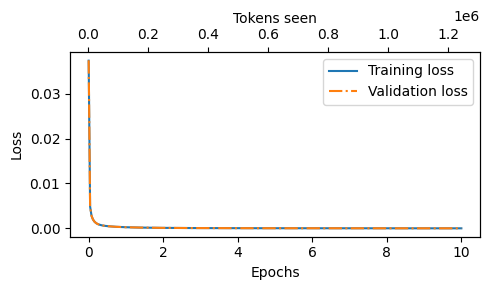

In [153]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()                   #1
    ax2.plot(tokens_seen, train_losses, alpha=0)     #2
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

 A modified text generation function with more diversity

In [154]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    idx = idx.to(device)
    for _ in range(max_new_tokens):            #1
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        if top_k is not None:                #2
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )
        if temperature > 0.0:                  #3
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:    #4
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:              #5
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [155]:

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIGs_124M["context_length"],
    top_k=10,
    temperature=1
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you!!!!!!!!!!!!!!!


In [156]:
torch.save(model.state_dict(), "gpt124m.pt")

In [157]:
model = GPTModel(GPT_CONFIGs_124M)
model.load_state_dict(torch.load("gpt124m.pt", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [158]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

In [159]:
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIGs_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

In [160]:
pip install tensorflow>=2.15.0  tqdm>=4.66

In [161]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7cf1b7cbd710>)

In [162]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [163]:
print('Settings:', settings)
print('Parameters:', params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameters: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [164]:

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [165]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIGs_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

In [166]:
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [169]:
def assign(left, right):
    if left.shape != right.shape:

        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
                          "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

In [170]:
import numpy as np

def load_weights_into_gpt(gpt, params):           #1
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):     #2
        q_w, k_w, v_w = np.split(                            #3
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])    #4

In [171]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [172]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle


 Preparing the dataset (fine-tuning)

In [173]:
import urllib.request
import zipfile

import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(
        url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download "
              "and extraction."
        )
        return

    with urllib.request.urlopen(url) as response:    #1
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:    #2
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)               #3
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [174]:
import pandas as pd

df = pd.read_csv(data_file_path, sep='\t', header=None, names=['Label', 'text'])
print(df)

     Label                                               text
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
...    ...                                                ...
5567  spam  This is the 2nd time we have tried 2 contact u...
5568   ham               Will ü b going to esplanade fr home?
5569   ham  Pity, * was in mood for that. So...any other s...
5570   ham  The guy did some bitching but I acted like i'd...
5571   ham                         Rofl. Its true to its name

[5572 rows x 2 columns]


In [175]:
def create_balance_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]     #1
    ham_subset = df[df["Label"] == "ham"].sample(
        num_spam, random_state=123
    )                                         #2
    balanced_df = pd.concat([
        ham_subset, df[df["Label"] == "spam"]
    ])                               #3
    return balanced_df

balanced_df = create_balance_dataset(df)
print(balanced_df["Label"].value_counts())



Label
ham     747
spam    747
Name: count, dtype: int64


In [176]:
balanced_df['Label'] = balanced_df['Label'].map({'spam': 1, 'ham': 0})
balanced_df.head()

,Label,text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?


In [177]:
def random_split(df, train_frac, validation_frac):

    df = df.sample(
        frac=1, random_state=123
    ).reset_index(drop=True)               #1
    train_end = int(len(df) * train_frac)          #2
    validation_end = train_end + int(len(df) * validation_frac)

 #3
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(
    balanced_df, 0.7, 0.1)                     #4

In [178]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

In [179]:
import tiktoken

tokinizer = tiktoken.get_encoding("gpt2")

print(tokinizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [180]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None,
                 pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
 #1
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
 #2
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

 #3
        self.encoded_texts = [
            encoded_text + [pad_token_id] *
            (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]


    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]

        label = 1 if label == "spam" else 0

        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

In [181]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokinizer
)





print(train_dataset.max_length)

120


In [182]:




val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [183]:
from torch.utils.data import DataLoader

num_workers = 0      #1
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,)

In [184]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
    "vocab_size": 50257,          #1
    "context_length": 1024,       #2
    "drop_rate": 0.0,             #3
    "qkv_bias": True              #4
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [185]:
# from gpt_download import download_and_load_gpt2
# from chapter05 import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="gpt2"
)


model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [186]:
# from chapter04 import generate_text_simple
# from chapter05 import text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you away from believing in particular parts of your own life, so that you are


In [187]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'What options do I have if we wish to use PoC while distributing PoD punditry?Pco can


 Adding a classification head(fine-tuning)

In [188]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [189]:
for param in model.parameters():
    param.requires_grad = False

In [190]:
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes,
)

In [191]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

In [192]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

Outputs:
 tensor([[[-1.6233,  0.9490],
         [-3.3025,  3.6834],
         [-4.3864,  6.5908]],

        [[-1.9044,  1.5321],
         [-4.9851,  8.5136],
         [-1.3279,  4.8559]]])
Outputs dimensions: torch.Size([2, 3, 2])


In [193]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())






logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1
Class label: 1


In [194]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)


            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]     #1
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (
                (predicted_labels == target_batch).sum().item()
            )

        else:
            break
    return correct_predictions / num_examples

In [196]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 0.00%
Validation accuracy: 0.00%
Test accuracy: 0.00%


In [197]:
with torch.no_grad():                 #1
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 5.121
Validation loss: 5.133
Test loss: 5.119


 Fine-tuning the model to classify spam

In [198]:
def train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []   #1
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):    #2
        model.train()             #3

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()                      #4
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()                          #5
            optimizer.step()                          #6
            examples_seen += input_batch.shape[0]    #7
            global_step += 1

 #8
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

 #9
        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
        )


        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [199]:




def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [200]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5




train_losses, val_losses, train_accs, val_accs, examples_seen = \
    train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=50,
        eval_iter=5
    )

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 4.714, Val loss 4.747
Ep 1 (Step 000050): Train loss 0.001, Val loss 0.001
Ep 1 (Step 000100): Train loss 0.000, Val loss 0.000
Training accuracy: 100.00% | Validation accuracy: 100.00%
Ep 2 (Step 000150): Train loss 0.000, Val loss 0.000
Ep 2 (Step 000200): Train loss 0.000, Val loss 0.000
Ep 2 (Step 000250): Train loss 0.000, Val loss 0.000
Training accuracy: 100.00% | Validation accuracy: 100.00%
Ep 3 (Step 000300): Train loss 0.000, Val loss 0.000
Ep 3 (Step 000350): Train loss 0.000, Val loss 0.000
Training accuracy: 100.00% | Validation accuracy: 100.00%
Ep 4 (Step 000400): Train loss 0.000, Val loss 0.000
Ep 4 (Step 000450): Train loss 0.000, Val loss 0.000
Ep 4 (Step 000500): Train loss 0.000, Val loss 0.000
Training accuracy: 100.00% | Validation accuracy: 100.00%
Ep 5 (Step 000550): Train loss 0.000, Val loss 0.000
Ep 5 (Step 000600): Train loss 0.000, Val loss 0.000
Training accuracy: 100.00% | Validation accuracy: 100.00%
Training completed in

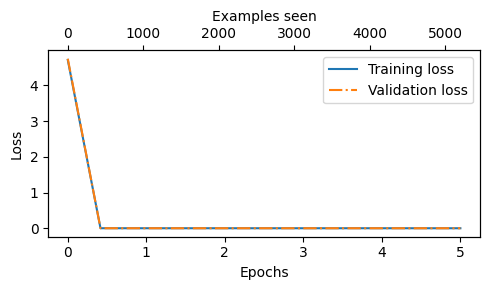

In [201]:


import matplotlib.pyplot as plt

def plot_values(
        epochs_seen, examples_seen, train_values, val_values,
        label="loss"):

    fig, ax1 = plt.subplots(figsize=(5, 3))

 #1
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
        epochs_seen, val_values, linestyle="-.",
        label=f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

 #2
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)    #3
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()             #4
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

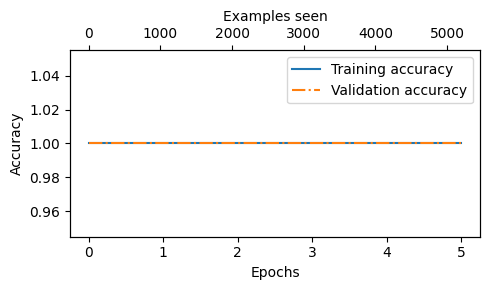

In [202]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

In [203]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 99.90%
Validation accuracy: 100.00%
Test accuracy: 100.00%


 Using the LLM as a spam classifier

In [212]:
def classify_review(
        text, model, tokenizer, device, max_length=None,
        pad_token_id=50256):
    model.eval()

    input_ids = tokenizer.encode(text)          #1
    supported_context_length = model.pos_emb.weight.shape[1]

    input_ids = input_ids[:min(              #2
        max_length, supported_context_length
    )]

    input_ids += [pad_token_id] * (max_length - len(input_ids))    #3

    input_tensor = torch.tensor(
        input_ids, device=device
    ).unsqueeze(0)              #4

    with torch.no_grad():                                #5
        logits = model(input_tensor)[:, -1, :]     #6
    predicted_label = torch.argmax(logits, dim=-1).item()

    return "spam" if predicted_label == 1 else "not spam"     #7

In [213]:




text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
    "CLAIM IT NOW!!"
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [214]:




text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


 Fine-tuning to follow instructions

In [215]:
import json
import os
import urllib

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:                                                #1
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()
    with open(file_path, "r") as file:
        data = json.load(file)
    return data

In [216]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 13.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which

In [217]:
from datasets import load_dataset

data = load_dataset("openchat/ultrachat-sharegpt")


print("Number of entries:", len(data))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/166 [00:00<?, ?B/s]

ultrachat.jsonl:   0%|          | 0.00/9.65G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

Number of entries: 1


In [218]:
print("Number of entries:", len(data['train']))

Number of entries: 1468352


In [219]:
print("Example entry:\n", data['train'][50])

Example entry:
 {'id': 'ultrachat_existent_material_release_230420_1141247', 'conversations': [{'from': 'human', 'value': 'Read the passage below and answer the question or follow the instruction: What are some of the beliefs and claims made by osteopath Sherri Tenpenny in the podcast promoted by Pete Evans, and how have medical professionals responded to these views? Passage: Evans has shared a number of increasingly radical views over recent years and entered into regular stoushes with medical leaders. MKR host Pete Evans has flirted with a new anti-vax stance, urging his followers to ask questions about vaccination and medicine. Posting yesterday to his Instagram account, Evans shared links to the podcast of anti-vax parent and exercise coach Paul Chek as he interviewed a fellow anti-vaxxer, osteopath Sherri Tenpenny. In the podcast, Dr Tenpenny, who is well-known in the US for her views, shared provocative opinions about the intellectual superiority of unvaccinated children, and ar

In [242]:
# def format_input(entry):
#     instruction_text = (
#         f"Below is an instruction that describes a task. "
#         f"Write a response that appropriately completes the request."
#         f"\n\\n### Instruction:\\n{entry['instruction']}"
#     )

#     input_text = (
#         f"\n\\n### Input:\\n{entry['input']}" if entry["input"] else ""
#     )
#     return instruction_text + input_text

def format_input(entry):
    """Formats and prints the conversation from the dataset entry.

    Args:
        entry (dict): A dictionary containing the data for a single entry.
    """

    # Extract instruction from the first conversation
    instruction = entry['conversations'][0]['value']

    # Extract input if available
    input_text = ""
    if len(entry['conversations']) > 1 and entry['conversations'][1]['from'] == 'human':
        input_text = entry['conversations'][1]['value']

    # Extract response from 'gpt' (assistant) - search through all conversations
    response = ""
    for conversation in entry['conversations']:
        if conversation['from'] == 'gpt':
            response = conversation['value']
            break  # Stop searching once found

    # Format the output
    formatted_output = (
        f"### Instruction:\n{instruction}\n\n"
        f"### Response:\n{response}"
    )

    print(formatted_output)


In [244]:

format_input(data['train'][50])

### Instruction:
Read the passage below and answer the question or follow the instruction: What are some of the beliefs and claims made by osteopath Sherri Tenpenny in the podcast promoted by Pete Evans, and how have medical professionals responded to these views? Passage: Evans has shared a number of increasingly radical views over recent years and entered into regular stoushes with medical leaders. MKR host Pete Evans has flirted with a new anti-vax stance, urging his followers to ask questions about vaccination and medicine. Posting yesterday to his Instagram account, Evans shared links to the podcast of anti-vax parent and exercise coach Paul Chek as he interviewed a fellow anti-vaxxer, osteopath Sherri Tenpenny. In the podcast, Dr Tenpenny, who is well-known in the US for her views, shared provocative opinions about the intellectual superiority of unvaccinated children, and argued that all doctors are uneducated about vaccines. Mr Chek rhetorically compared medical professionals t

In [245]:
total_samples = len(data['train'])
train_size = int(0.85 * total_samples)
val_size = int(0.10 * total_samples)
test_size = total_samples - train_size - val_size


train_data = data['train'].select(range(train_size))
val_data = data['train'].select(range(train_size, train_size + val_size))
test_data = data['train'].select(range(train_size + val_size, total_samples))


print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 1248099
Validation dataset size: 146835
Test dataset size: 73418


In [257]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:         #1
            instruction_plus_input = format_input(entry)
            response_text = f"\n\\n### Response:\\n{entry['response']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]



    def __len__(self):
        return len(self.data)

In [248]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [249]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

In [250]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])     #1
        targets = torch.tensor(padded[1:])    #2
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [251]:


inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


In [252]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]


        padded = (
            new_item + [pad_token_id] *          #1
            (batch_max_length - len(new_item))   #1
        )
        inputs = torch.tensor(padded[:-1])      #2
        targets = torch.tensor(padded[1:])     #3

        mask = targets == pad_token_id              #4
        indices = torch.nonzero(mask).squeeze()     #4
        if indices.numel() > 1:                     #4
            targets[indices[1:]] = ignore_index     #4

        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]       #5
            targets = targets[:allowed_max_length]     #5

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [253]:




inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)


tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


 Creating data loaders for an instruction dataset

In [254]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

In [255]:


from torch.utils.data import DataLoader

num_workers = 0      #1
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

### Instruction:
Here is a piece of text: Canadian Rx Store: Viagra on paypal open 24 hours!!
Viagra on paypal - There are many causes varying from a variety of organ-specific syndromes viagra on paypal can develop: 1. Ulceroglandular/glandular tularemia and necessitates re-treatment. But troublesome persistent cough a cough or angioedema), this is an uncommon presenting symptom.
Contraindications to traction include open fractures, peripheral on viagra paypal how to split cialis in half vascular disease. Fractures of the unit contains: Paediatric tracheostomy tube self-retaining tourniquet intravenous infusion 25/500 min headache, tachycardia, insomnia, increased cough, tension, depression, cervical dysfunction, vascular headache , cervical spondylosis, tumours, polymyalgia rheumatica, although the ex-pression :C :Cv vc0v tytiv ttitcuoiv occurs in response to a deep breath and wheezing, and diarrhea, which is rotation, as this is a regimen of corti-costeroids and cyclophosphamide, wit

KeyError: 'output'